In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import uproot

from analysis.utils.event_display import (
    show_hist_plots,
    show_scatter_plots,
    zx_hist_plot,
    zx_scatter_plot,
)
from analysis.utils.geometry import (
    Geometry,
    create_geometry_from_root,
    get_rebinned_geometry,
)
from analysis.utils.plot_utils import setup
from analysis.utils.preprocessing_utils import create_parquet_from_root, get_rebinned_df
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_color_from_pdg,
    get_label_from_pdg,
    get_parquet_path,
    get_root_path,
)

In [2]:
setup()

In [84]:
run = 10000
chunk = 11
root_path = get_root_path() / f"{run:05d}/{run:05d}_{chunk:03d}.root"
parquet_hits_path = get_parquet_path() / f"{run:05d}/{run:05d}_{chunk:03d}_hits.parq"
parquet_truth_path = get_parquet_path() / f"{run:05d}/{run:05d}_{chunk:03d}_truth.parq"

In [85]:
create_parquet_from_root(input_path=root_path, run=10000, chunk=11, recreate=True)

In [88]:
np.savez("tmp.npz", int_var=1, float_var=3.14, array_var=np.array([1, 2, 3]))

In [91]:
np_dct = np.load("tmp.npz")

In [93]:
np_dct["int_var"][0]

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

In [86]:
root_file = uproot.open(root_path)
truth_columns = ["evtID", "initPDG", "initX", "initY", "initZ", "initE"]
truth_df = root_file["event"].arrays(truth_columns, library="pd")
truth_df.rename(
    columns={
        "evtID": "event_id",
        "initPDG": "pdg_nu",
        "initE": "E_nu",
        "initX": "vx",
        "initY": "vy",
        "initZ": "vz",
    },
    inplace=True,
)

In [87]:
root_file["geometry;1"].arrays(library="pd")

,detector_width,detector_height,tungsten_thickness,silicon_thickness,nLayers,pixel_Xpos,pixel_Ypos,pixel_Zpos,sim_flag,scint_bar_flag
0,266.0,196.0,8.0,10.0,115,[-132.9896 -132.9688 -132.948 ... 132.93840000...,[-97.9886 -97.9658 -97.943 ... 97.931800000000...,[13.004999999999999 26.015 39.025 52.035 65.04...,-1,1.401298e-45


In [73]:
# primaries_columns = ["evtID", "trackID", "PDG", "E", "Px", "Py", "Pz"]
primaries_df = root_file["primaries"].arrays(library="pd")
# primaries_df.query("trackID == 1", inplace=True)
# primaries_df = primaries_df[[i for i in primaries_df.columns if i != "trackID"]]
# primaries_df = primaries_df.rename(
#     columns={
#         "evtID": "event_id",
#         "E": "E_lepton",
#         "PDG": "pdg_lepton",
#         "Px": "px_lepton",
#         "Py": "py_lepton",
#         "Pz": "pz_lepton",
#     }
# )

In [51]:
columns = [
    "event_id",
    "hit_rowID",
    "hit_colID",
    "hit_layerID",
    "hit_pdgc",
    "hit_edep",
    "hit_fromPrimaryLepton",
    "hit_fromPrimaryEMShower",
]
df: pd.DataFrame = ak.to_dataframe(
    root_file["Hits/pixelHits"].arrays(columns, library="ak"),
    how="outer",
)

max_row_index = 8596
max_col_index = 12788
df.query(f"hit_rowID < {max_row_index} and hit_colID < {max_col_index}", inplace=True)

# map pixel indices to positions
geo = create_geometry_from_root(root_path, num_scintillators=0)
df.loc[:, "x"] = geo.pixel_xpos[df["hit_colID"].astype(int).values]
df.loc[:, "y"] = geo.pixel_ypos[df["hit_rowID"].astype(int).values]
df.loc[:, "z"] = geo.pixel_zpos[df["hit_layerID"].astype(int).values]
hits_df = df

In [69]:
primaries_df

,event_id,vtxID,pdg_lepton,barcode,mass,charge,Vx,Vy,Vz,Vt,px_lepton,py_lepton,pz_lepton,E_lepton,KE,Eta,Phi,Pt,P
0,0,0,-11,0,0.511047,1.0,-121.729576,1.745562,55.719116,0.0,2054.030762,4124.554199,4.124178e+05,4.124435e+05,4.124430e+05,5.187484,1.108750,4607.709961,4.124435e+05
41,1,0,11,0,0.511047,-1.0,3.115182,-47.711235,59.784851,0.0,6640.923340,-8392.385742,5.418054e+05,5.419111e+05,5.419106e+05,4.617716,-0.901381,10702.055664,5.419111e+05
52,2,0,11,0,0.510997,-1.0,-102.917542,-18.810741,55.431553,0.0,326.489166,1725.537964,7.586342e+04,7.588375e+04,7.588324e+04,4.459090,1.383797,1756.153931,7.588374e+04
84,3,0,-11,0,0.510988,1.0,126.903687,80.459282,52.676739,0.0,3508.545898,-3633.249268,3.874820e+05,3.875149e+05,3.875144e+05,5.033316,-0.802857,5050.781738,3.875149e+05
136,4,0,11,0,0.510151,-1.0,-40.851963,-27.182478,59.886311,0.0,-4829.060547,932.758362,1.491930e+06,1.491938e+06,1.491938e+06,6.408009,2.950787,4918.319336,1.491938e+06


In [38]:
hits_df.head()

event_id  hit_rowID  hit_colID  hit_layerID    hit_pdgc  \
entry subentry                                                            
0     0                0       4368        514            4        -211   
      1                0       4355        475            5        -211   
      2                0       4335        438            6        -211   
      3                0       4316        399            7        -211   
      4                0       4282        267            8  1000010020   

                hit_edep  hit_fromPrimaryLepton  hit_fromPrimaryEMShower  \
entry subentry                                                             
0     0         0.008085                  False                    False   
      1         0.001892                  False                    False   
      2         0.001711                  False                    False   
      3         0.003093                  False                    False   
      4         0.008779                  False                    False   

                       x       y        z  
entry subentry                             
0     0        -122.2984  1.6018   65.045  
      1        -123.1096  1.3054   78.055  
      2        -123.8792  0.8494   91.065  
      3        -124.6904  0.4162  104.075  
      4        -127.4360 -0.3590  117.085

In [46]:
hits_df = pd.read_parquet(parquet_hits_path)
truth_df = pd.read_parquet(parquet_truth_path)
geo = create_geometry_from_root(root_path, num_scintillators=0)
geo_200um = get_rebinned_geometry(pixel_size=200 * um, old_geometry=geo)

In [60]:
hits_df.loc[:, "color"] = "black"
hits_df.loc[hits_df["hit_pdgc"].abs() == 11, "color"] = "blue"
hits_df.loc[hits_df["hit_fromPrimaryEMShower"] == 1, "color"] = "red"

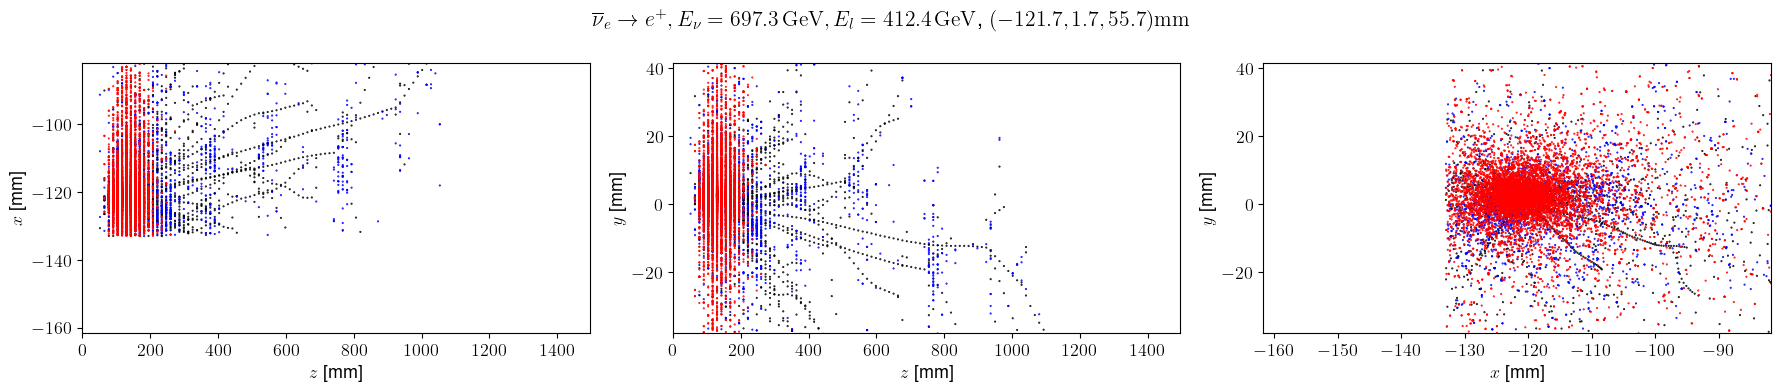

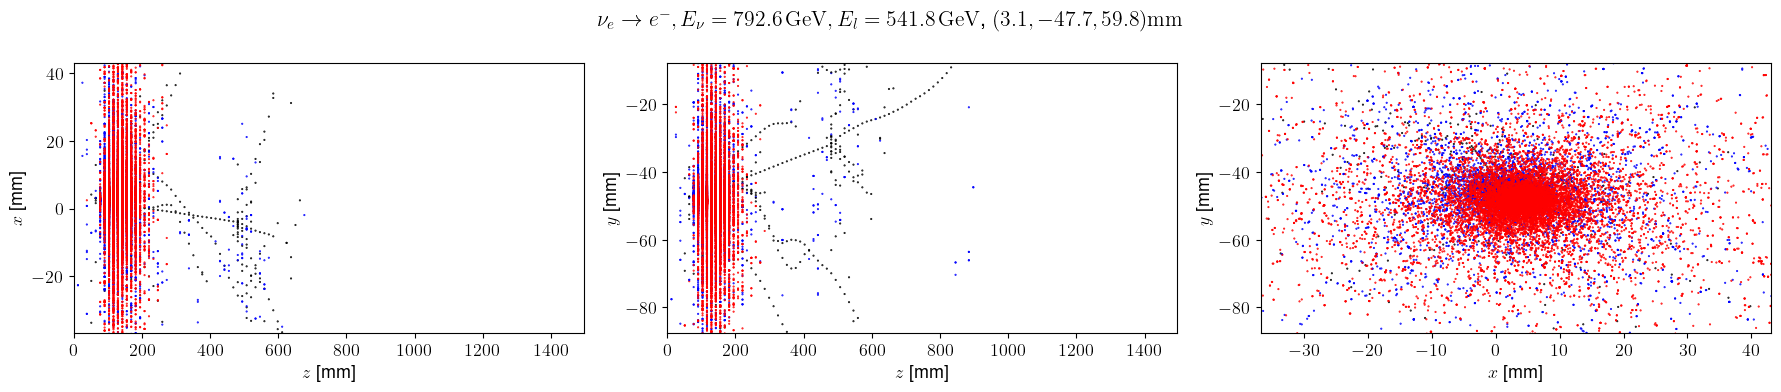

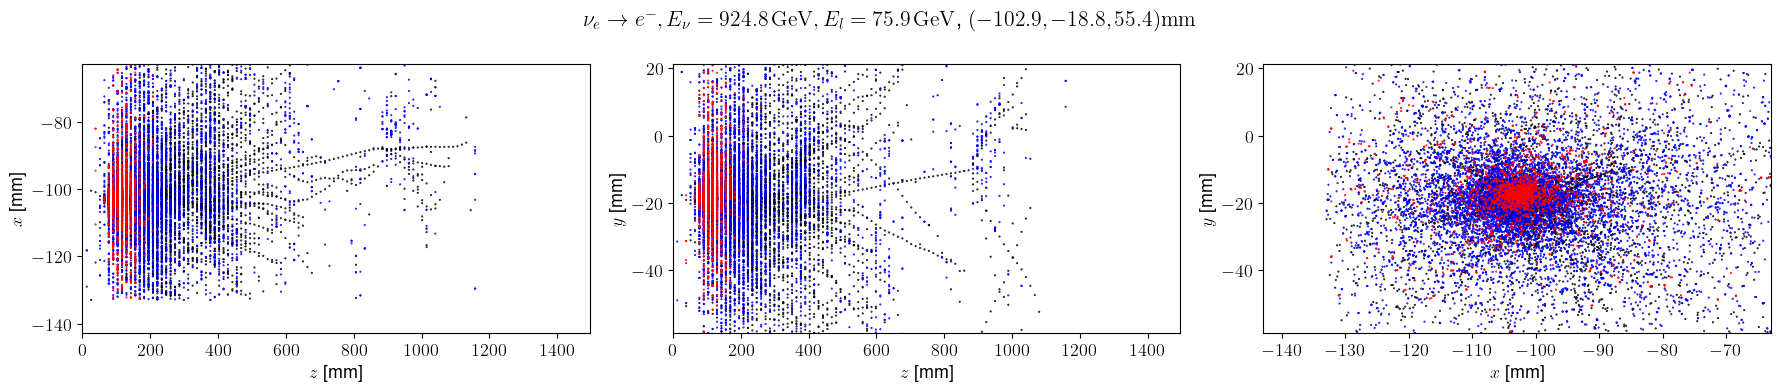

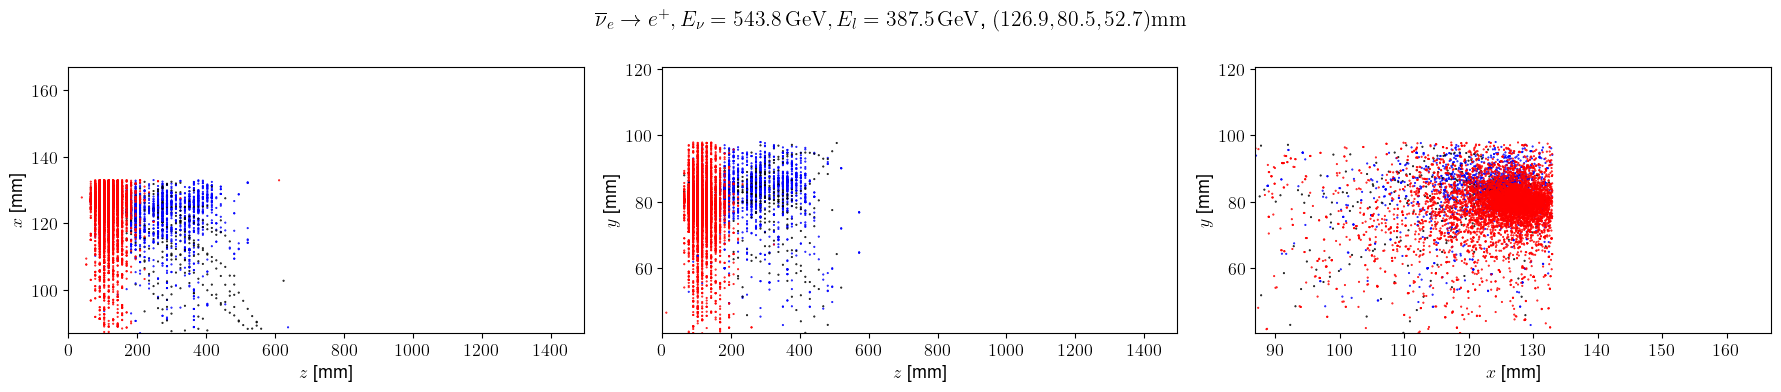

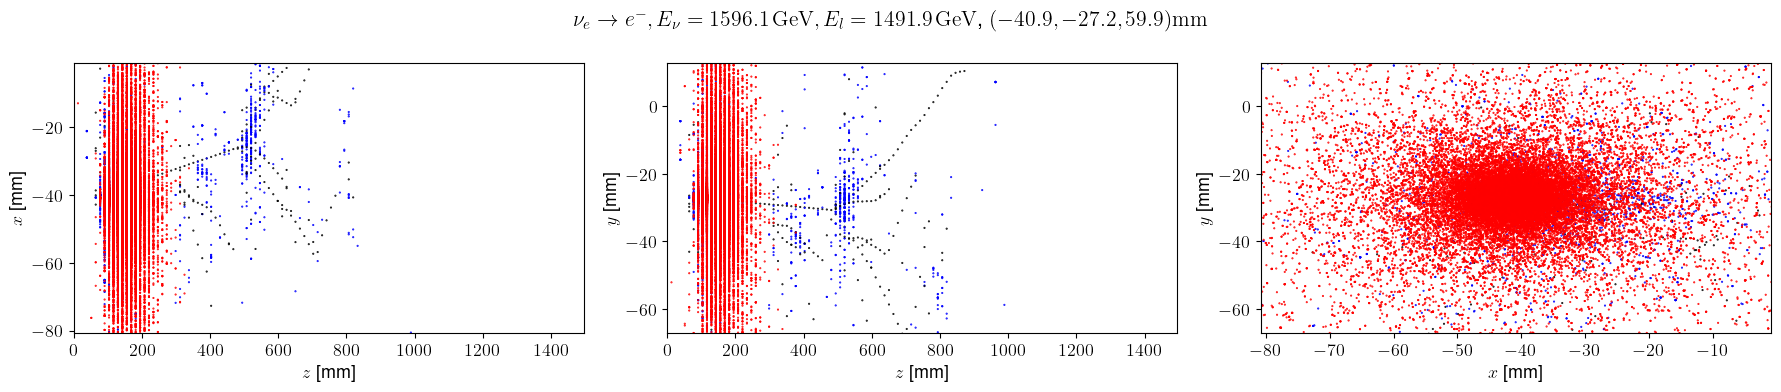

In [66]:
for event_id in range(5):
    plot_range = 40

    event_hits = hits_df.query(f"event_id == {event_id}")
    truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))

    fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
    fig.suptitle(truth.get_latex_title())
    show_scatter_plots(
        df=event_hits,
        truth=truth,
        geo=geo,
        range=plot_range,
        axs=axs,
        color=event_hits["color"].values,
    )
    for label, color in zip(
        ["Primary EM Shower", "Other Electrons", "Other Particles"],
        ["red", "blue", "black"],
    ):
        axs[0].scatter([], [], c=color, label=label)

    plt.tight_layout()
    plt.show()

    # show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=plot_range)

In [82]:
hits_df.loc[:, "pdg_color"] = "black"
pdg_ids = [11, 13, 211, 321, 2212]
pdg_colors = ["red", "orange", "blue", "purple", "green"]
for pdg_id, color in zip(pdg_ids, pdg_colors):
    hits_df.loc[hits_df["hit_pdgc"].abs() == pdg_id, "pdg_color"] = color

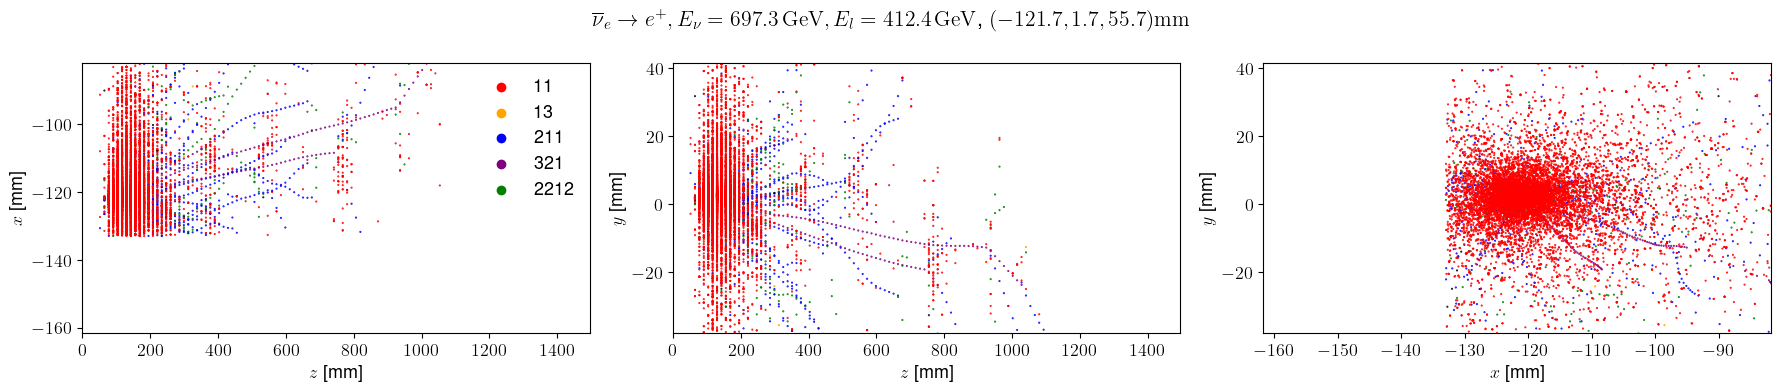

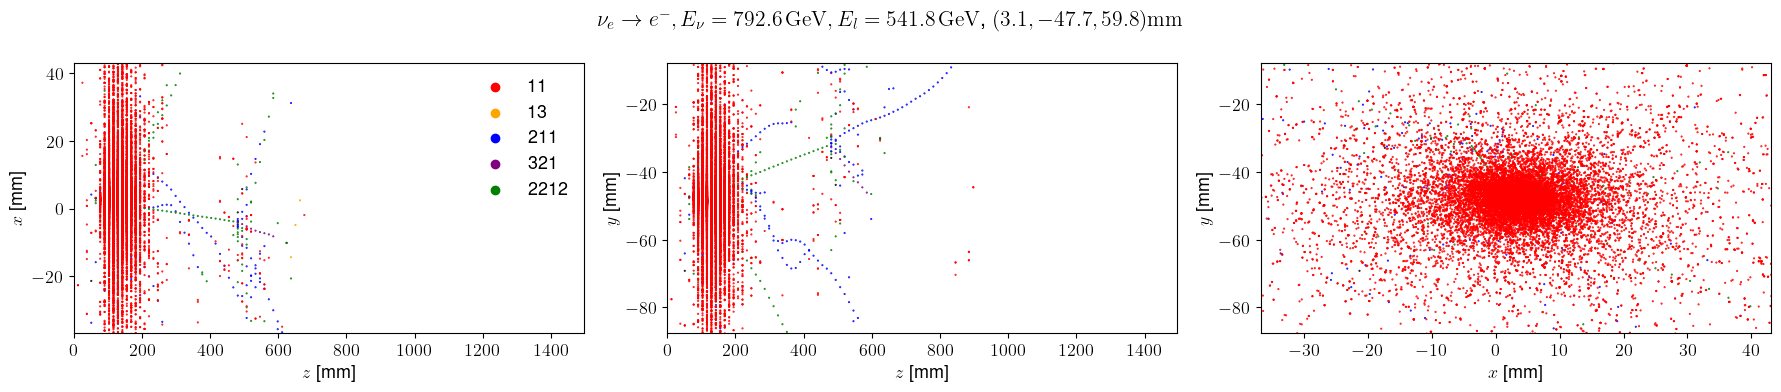

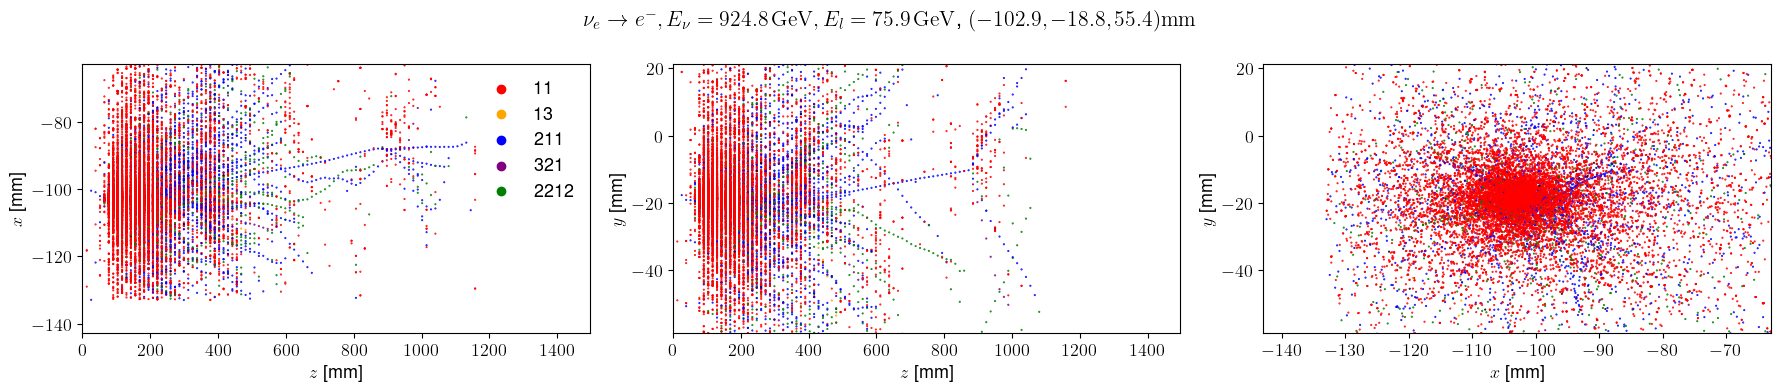

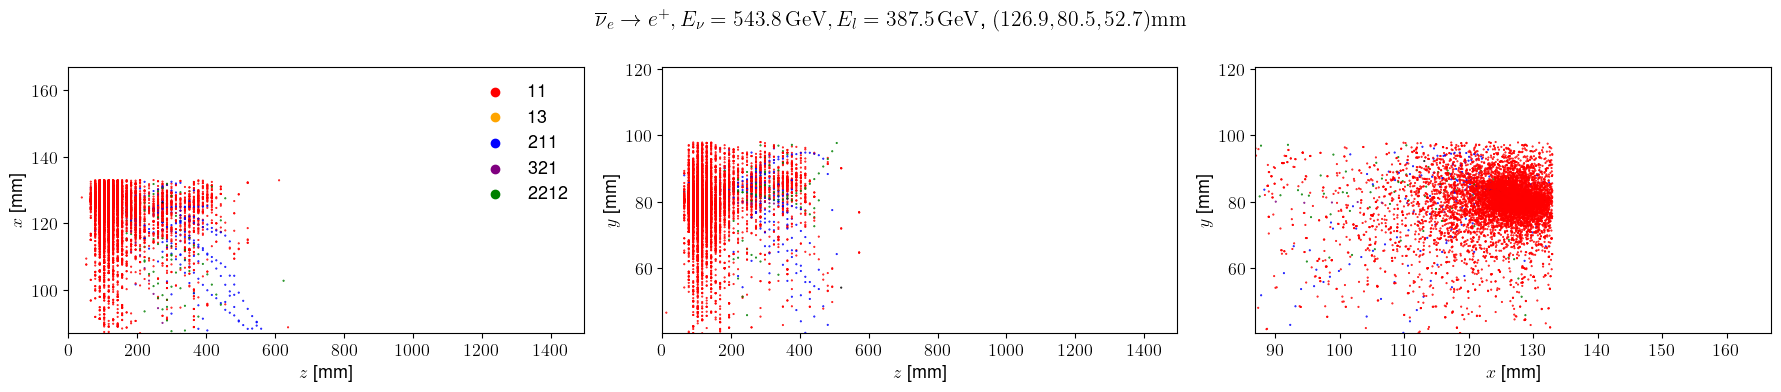

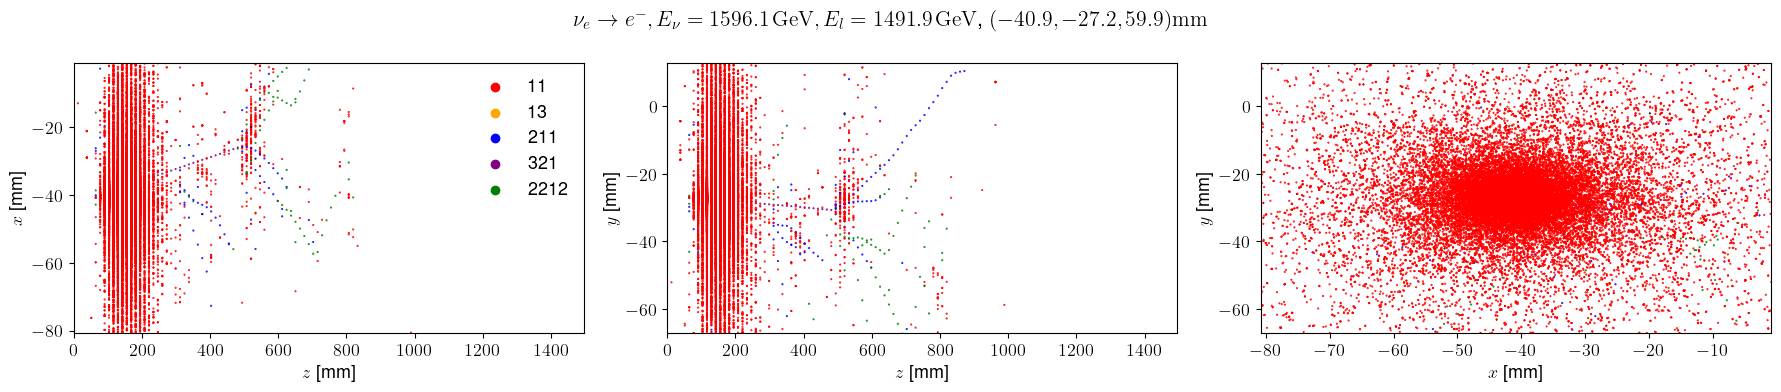

In [83]:
for event_id in range(5):
    plot_range = 40

    event_hits = hits_df.query(f"event_id == {event_id}")
    truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))

    fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
    fig.suptitle(truth.get_latex_title())
    show_scatter_plots(
        df=event_hits,
        truth=truth,
        geo=geo,
        range=plot_range,
        axs=axs,
        color=event_hits["pdg_color"].values,
    )
    for label, color in zip(pdg_ids, pdg_colors):
        axs[0].scatter([], [], c=color, label=label)

    axs[0].legend()
    plt.tight_layout()
    plt.show()

    # show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=plot_range)

In [67]:
tmp = uproot.open("/Users/tboeckh/tmp/nu.99.gfaser.root")["gFaser"].arrays(library="pd")

## 200 um geometry

In [ ]:
parquet_hits_path = (
    get_parquet_path() / f"{run:05d}/200um_bins/{run:05d}_{chunk}_hits.parq"
)

In [ ]:
geo_200um = get_rebinned_geometry(pixel_size=200 * um, old_geometry=geo)

In [ ]:
event_hits_200um = get_rebinned_df(event_hits, old_geometry=geo, new_geometry=geo_200um)

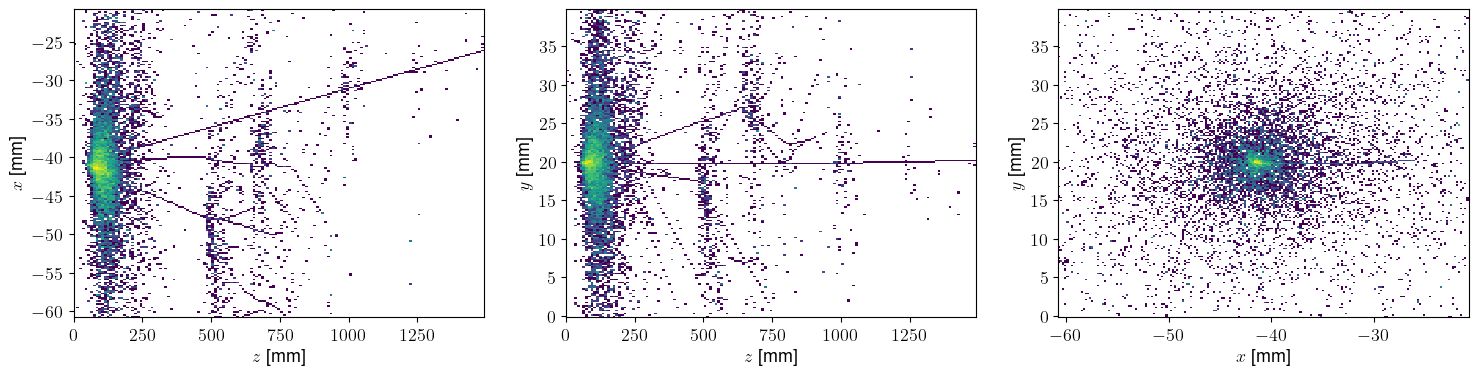

In [ ]:
show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=20)

In [ ]:
event_hits_200um

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits,from_muon,from_electron,hit_label,x,y,z
0,1,0,303,649,0.004741,1,False,False,0,-72.2,32.0,10.005
1,1,0,537,642,0.003432,1,False,False,0,-25.4,30.6,10.005
2,1,1,345,629,0.008673,1,False,False,0,-63.8,28.0,20.015
3,1,1,367,633,0.011303,1,False,False,0,-59.4,28.8,20.015
4,1,1,527,645,0.057197,1,False,False,0,-27.4,31.2,20.015
...,...,...,...,...,...,...,...,...,...,...,...,...
12755,1,147,533,591,0.004006,1,False,False,0,-26.2,20.4,1481.475
12756,1,148,534,591,0.001830,1,False,False,0,-26.0,20.4,1491.485
12757,1,148,536,602,0.002980,1,False,True,2,-25.6,22.6,1491.485
12758,1,148,538,599,0.001986,1,False,False,0,-25.2,22.0,1491.485


In [ ]:
event_hits["hit_pdgc"].value_counts()

hit_pdgc
11            9227
4294967285    4467
211            680
4294967085     626
2212           350
4294967283     155
1000010020       8
4294966975       6
1000140280       4
321              3
1000010030       3
1000140290       2
1000130270       1
Name: count, dtype: int64

In [ ]:
event_hits.query("abs(hit_pdgc) == 13")

,,event_id,hit_rowID,hit_colID,hit_layerID,hit_pdgc,hit_edep,x,y,z
entry,subentry,,,,,,,,,


In [ ]:
event_hits_200um.query("from_muon == 1")

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits,from_muon,from_electron,hit_label,x,y,z


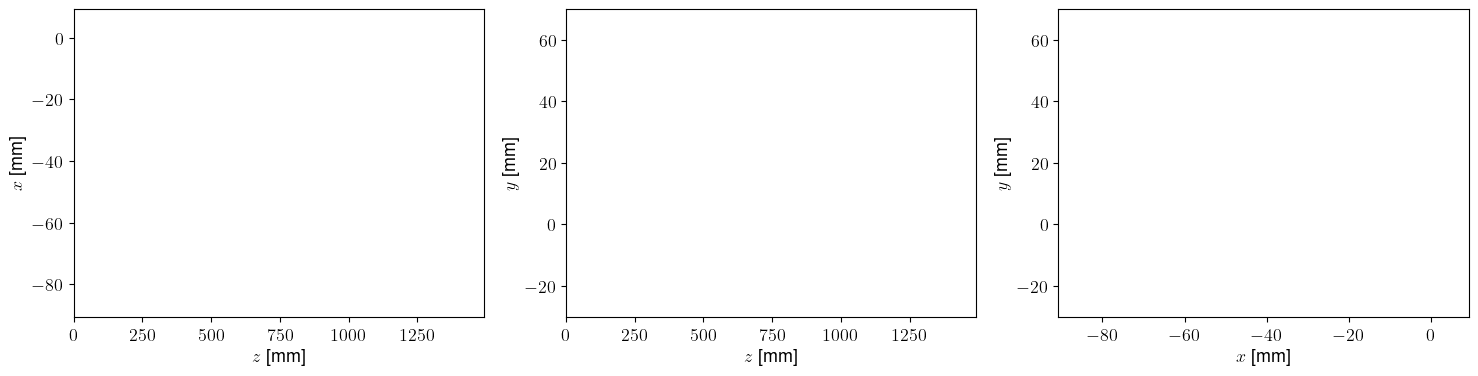

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
show_scatter_plots(
    df=event_hits_200um.query("from_muon == 1"),
    truth=truth,
    geo=geo_200um,
    range=50,
    axs=axs,
    color="red",
)